In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pylab import rcParams
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from xgboost import XGBClassifier


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv


# Predictive Maintenance using Isolation Forest and Random Forest

## Objective
This project aims to build an intelligent predictive maintenance pipeline capable of:

- Detecting anomalous machine behavior
- Predicting future machine failures
- Explaining model decisions using SHAP

## Industrial Relevance
Predictive maintenance reduces:
- Downtime
- Maintenance costs
- Equipment failures

This notebook simulates a real-world Industry 4.0 maintenance workflow.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020/ai4i2020.csv")
print(df.head(),df.columns) #Printing Basic Information about the dataset

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [3]:
print(df.info(),df.shape) #Checking for data types 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
#Performing label encodings for object features
df["Type"].unique() #array(['M', 'L', 'H'], dtype=object)
df = pd.get_dummies(
    df,
    columns=['Type'],
    prefix='MachineType',
    drop_first=True
)  

In [5]:
#Checking Null values
df.isnull().sum()

UDI                        0
Product ID                 0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
MachineType_L              0
MachineType_M              0
dtype: int64

<Axes: >

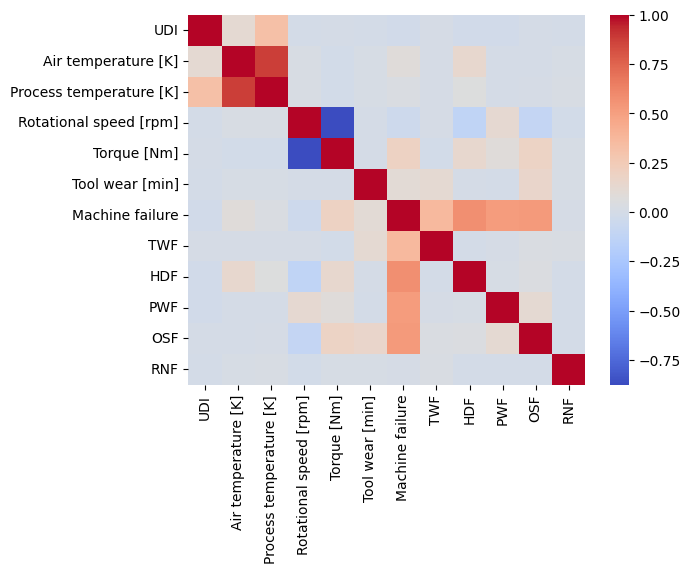

In [6]:
sns.heatmap(df.select_dtypes(include='number').corr(),cmap='coolwarm')
#Feature HDF is strongly correlated to prediction output

In [7]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import RandomizedSearchCV

X = df.drop(columns=['Machine failure',"Product ID"])

"""
Lower decision_function scores
indicate more anomalous samples.

We maximize anomaly separation
by minimizing average score.
"""

def anomaly_scorer(estimator, X):
    scores = estimator.decision_function(X)
    return -np.mean(scores)
    

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('iso', IsolationForest(
        random_state=42
    ))
])

param_dist = {
    'iso__n_estimators': [100, 200, 300],
    'iso__max_samples': [0.5, 0.75, 1.0],
    'iso__max_features': [0.5, 0.75, 1.0],
    'iso__contamination': [0.03, 0.05, 0.08]
}

params = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring=anomaly_scorer,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

params.fit(X)
best_model = params.best_estimator_

print("Best Parameters:\n")
print(params.best_params_)
preds = best_model.predict(X)

def convert_anomaly(value):

    if value == -1:
        return 1
    
    return 0

df['Anomaly Detection'] = pd.Series(preds).apply(convert_anomaly)


print("\nAnomaly Distribution:\n")
print(df['Anomaly Detection'].value_counts())
print("\nSample Data:\n")
print(df['Anomaly Detection'].head())

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters:

{'iso__n_estimators': 200, 'iso__max_samples': 1.0, 'iso__max_features': 0.75, 'iso__contamination': 0.08}

Anomaly Distribution:

Anomaly Detection
0    9200
1     800
Name: count, dtype: int64

Sample Data:

0    0
1    0
2    0
3    0
4    0
Name: Anomaly Detection, dtype: int64


#MODEL WORKFLOW


* Raw Data
     *  ↓
* EDA
     *  ↓
* Isolation Forest
     *  ↓
* Anomaly Labels
     *  ↓
* Feature Engineering
     *  ↓
* Random Forest Classifier
     *  ↓
* SHAP Explainability
     *  ↓
* Maintenance Insights

In [8]:
X_new=df.drop(columns=["Product ID","Machine failure"])
Y_new=df["Machine failure"]
X_new.head()

# Remove column names with other charachters
import re

# Clean column names
X_new.columns = [
    re.sub(r'[^A-Za-z0-9_]+', '_', col)
    for col in X_new.columns
]

# View cleaned names
print(X_new.columns)

Index(['UDI', 'Air_temperature_K_', 'Process_temperature_K_',
       'Rotational_speed_rpm_', 'Torque_Nm_', 'Tool_wear_min_', 'TWF', 'HDF',
       'PWF', 'OSF', 'RNF', 'MachineType_L', 'MachineType_M',
       'Anomaly_Detection'],
      dtype='object')


In [9]:
#Using Random Forest Algorithm to predict Machine Failure

#Train Test Split

x_train,X_test,y_train,Y_test=train_test_split(X_new,Y_new,test_size=0.3,random_state=42)
x_val,x_test,y_val,y_test=train_test_split(X_test,Y_test,test_size=0.5,random_state=42)
print(x_train.shape,x_val.shape,x_test.shape)
RANDOM_STATE = 55

# Handle class imbalance
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())

scale_pos_weight = max(1.0, neg_count / max(pos_count, 1))

# Base Model
base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=2,
    scale_pos_weight=scale_pos_weight,
)

# Hyperparameter Grid
param_grid = {
    'n_estimators': [120, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0.0, 0.1, 0.3],
    'reg_lambda': [1, 3, 5],
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring='f1',   # Better than accuracy for imbalance-predictive maintenance
    cv=3,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# Train
random_search.fit(x_train, y_train)

# Best Model
best_model = random_search.best_estimator_

# Predictions
y_pred = best_model.predict(x_val)

# Metrics
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
cm = confusion_matrix(y_val, y_pred)

# Results
print("Accuracy:", accuracy)

print("\nF1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


(7000, 14) (1500, 14) (1500, 14)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=1, n_estimators=300, reg_lambda=3, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=1, n_estimators=300, reg_lambda=3, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.03, max_depth=8, min_child_weight=1, n_estimators=300, reg_lambda=3, subsample=0.8; total time=   0.3s
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, reg_lambda=1, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=200, reg_lambda=1, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=1.0, gamma=0.0, learning_rate=0.05, max_depth=6, min_child_weight=5, n_esti

In [10]:
#Test set model evaluation
# Predictions
y_pred = best_model.predict(x_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Results
print("Accuracy:", accuracy)

print("\nF1 Score:", f1)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.9986666666666667

F1 Score: 0.9772727272727273

Confusion Matrix:
[[1455    2]
 [   0   43]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1457
           1       0.96      1.00      0.98        43

    accuracy                           1.00      1500
   macro avg       0.98      1.00      0.99      1500
weighted avg       1.00      1.00      1.00      1500



<Axes: >

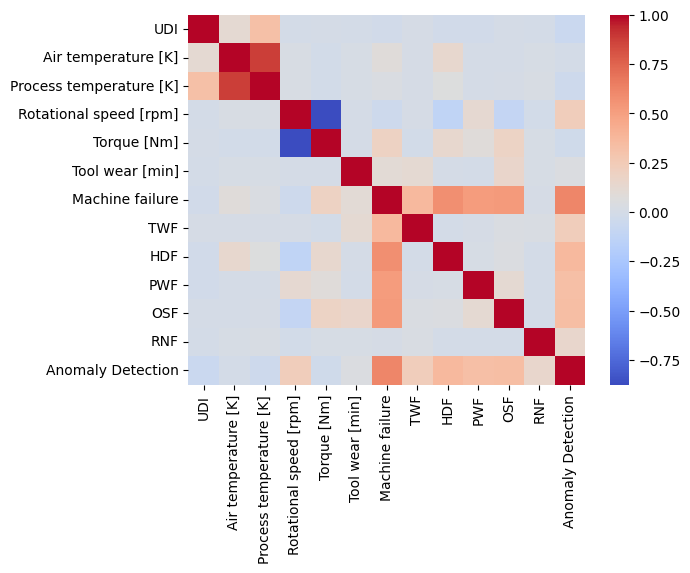

In [11]:

sns.heatmap(df.select_dtypes(include="number").corr(),cmap="coolwarm")

In [12]:
#Check if failure occurs when none of the features TWF,HDF,PWF,OSF,RNF were zero to check for no data leakages
count = df[
    (df['Machine failure'] == 1) &
    (df['TWF'] == 0) &
    (df['HDF'] == 0) &
    (df['PWF'] == 0) &
    (df['OSF'] == 0) &
    (df['RNF'] == 0)
].shape[0]

print(count)

9


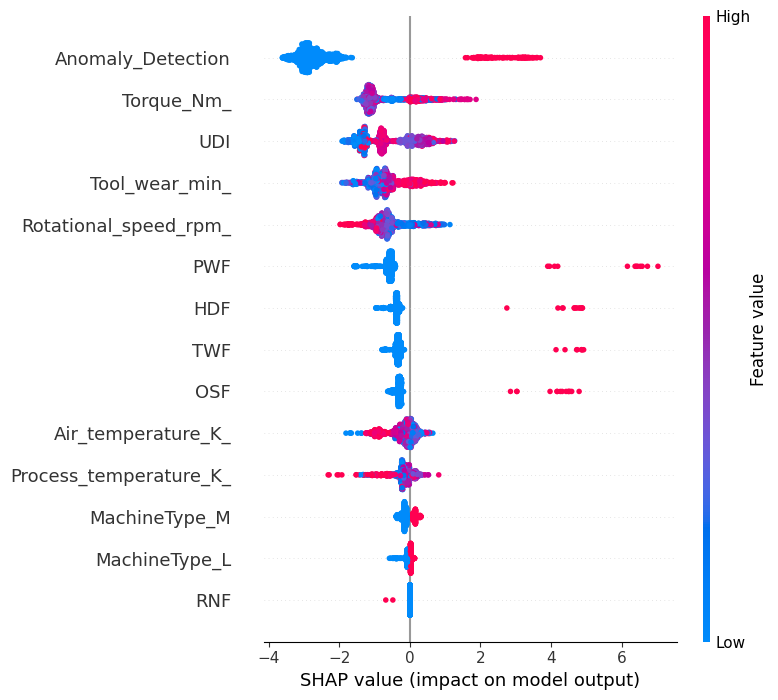

In [13]:
#Using SHAP to affirm the contribution of the new feature added for model evaluation
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(x_test)
shap.summary_plot(
    shap_values,
    x_test
)

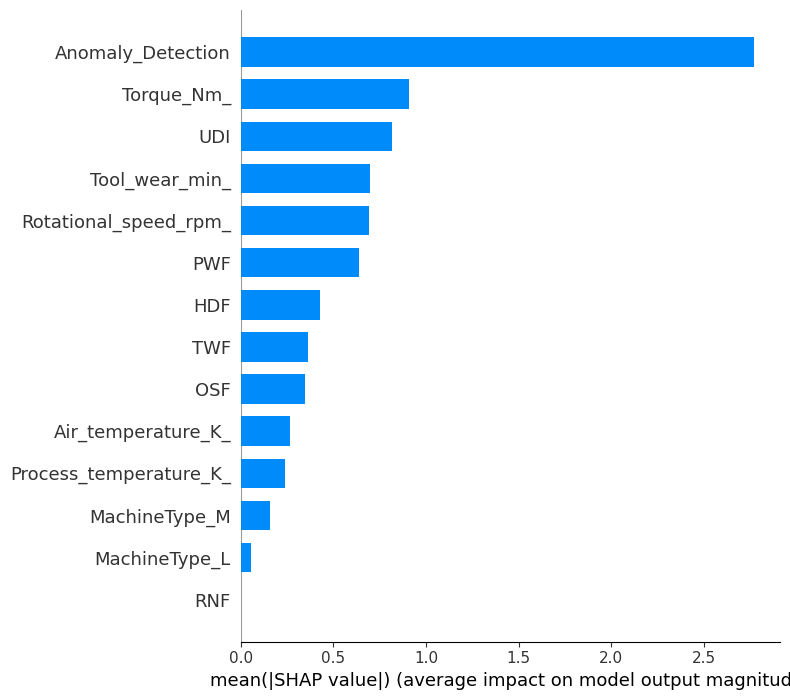

In [14]:
#Looking at feature importance bar plot
shap.summary_plot(
    shap_values,
    x_test,
    plot_type='bar'
)
#This shows that using Isolation Forest for feature engineering has significantly affected the model accuracy

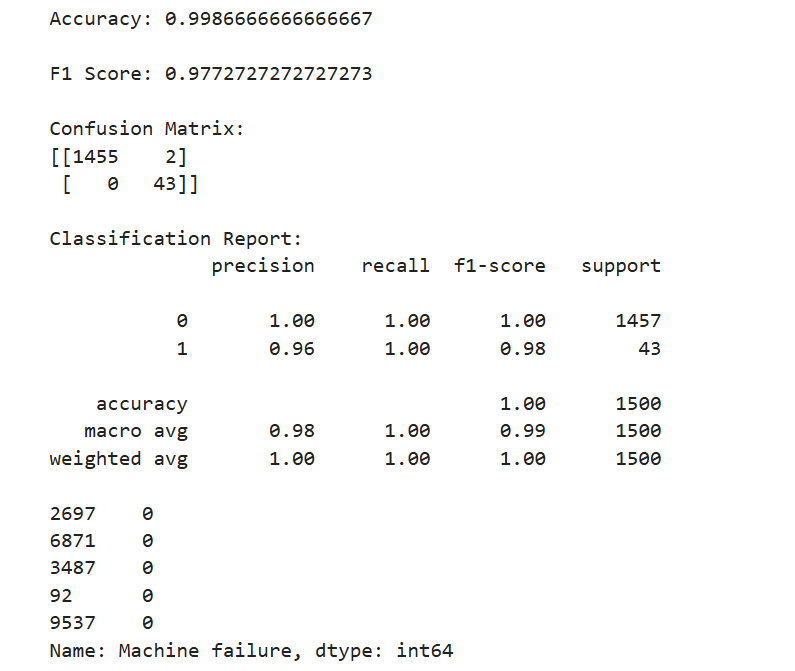
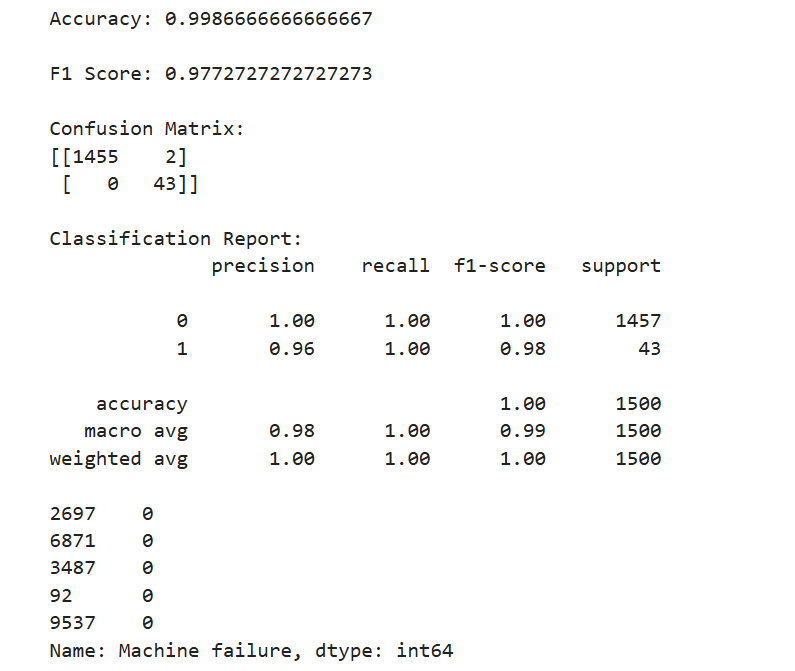